# 🚲 E-Bike Range Prediction using Linear Regression

## Problem Description

In this project, I build a simple linear regression model to predict the remaining range of an electric bike. 
The goal is to understand the fundamentals of supervised learning by implementing the model step by step and observing how the algorithm learns from data. 

## Dataset
For this first experiment, I use a simple dataset with one feature: 

**Feature(input):**
- Battery level (%)

**Target (Prediction):**
- Remaining range (km)

The dataset represents the relationship between the current battery level of an e-bike and its expected remaining range. 

## Objective

The objective is to implement linear regression from scratch, including: 
- model prediction
- cost function
- gradient descent optimization

After training, the model should be able to estimate the remaining range of an e-bike based on its battery level. 

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## 1. Generate Data:

In [462]:
np.random.seed(42)  # for reproducibility

number_of_samples = 25
battery_level = np.random.uniform(0, 100, number_of_samples)  # battery in %, single feature
noise = np.random.normal(0, 4, number_of_samples)  # random variation
range_km = 0.8 * battery_level + noise # target value

print(f"Number of training examples: {number_of_samples}")
display(pd.DataFrame({"battery_level": battery_level, "range_km": range_km}).head())

Number of training examples: 25


,battery_level,range_km
0,37.454012,27.445310
1,95.071431,78.448026
2,73.199394,68.797467
3,59.865848,49.469611
4,15.601864,12.970368


## 2. Visualize Data:

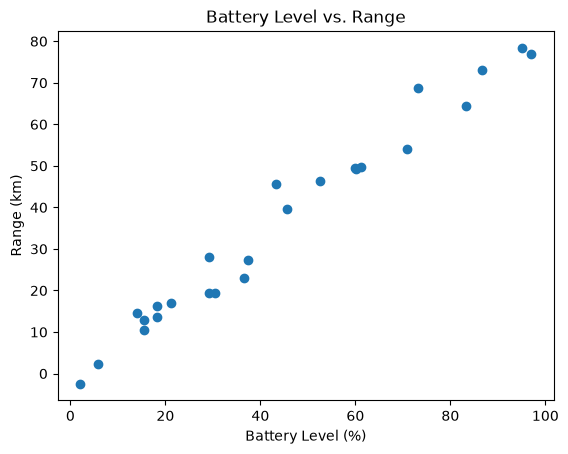

In [463]:
plt.scatter(battery_level, range_km)
plt.xlabel("Battery Level (%)")
plt.ylabel("Range (km)")
plt.title("Battery Level vs. Range")
plt.show()

## 3. Cost function (Mean Squared Error):
$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

where: $$f_{w,b}(x) = wx + b$$

In [464]:
def compute_cost(x, y, w, b):

    """Compute the mean squared error cost for linear regression.

    Args:
        x: input feature values
        y: target values
        w: model weight (slope)
        b: model bias (intercept)

    Returns:
        total_cost: the computed cost J(w,b)
    """
    
    m = x.shape[0] # number of training examples
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i])**2

    total_cost = cost / (2 * m)

    return total_cost

## 4. Gradient Function

**Gradient Descent update:**
$$w := w - \alpha\frac{\partial J}{\partial w}, \quad b := b - \alpha\frac{\partial J}{\partial b}$$

where parameters $w$, $b$ are updated simultaneously and $m$ is the number of training examples.

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})\, x^{(i)}
$$

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})
$$

In [465]:
def compute_gradient(x, y, w, b):

    """Compute the gradient of the cost function with respect to w and b.

    Args:
        x: input feature values
        y: target values
        w: model weight (slope)
        b: model bias (intercept)

    Returns:
        dj_dw: gradient of the cost with respect to w
        dj_db: gradient of the cost with respect to b
    """
    
    m = x.shape[0] # number of trainings examples
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += f_wb - y[i]

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

## 5. Gradient Descent

In [466]:
def gradient_descent(x, y, w_inital, b_inital, alpha, number_of_iterations, cost_function, gradient_function):
    """Perform gradient descent to fit w and b for linear regression.

    Args:
        x: input feature values
        y: target values
        w_inital: initial value of w
        b_inital: initial value of b
        alpha: learning rate
        number_of_iterations: number of gradient descent steps to run
        cost_function: function to compute the cost J(w,b)
        gradient_function: function to compute the gradients dj_dw, dj_db

    Returns:
        w: final learned weight
        b: final learned bias
        J_history: list of cost values at each iteration
    """

    J_history = []
    w = w_inital
    b = b_inital

    for i in range(number_of_iterations):

        dj_dw, dj_db = gradient_function(x, y, w, b)
                                 
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Save data at each iteration to print gradient descent process
        if i < 100000: # prevent ressource exhaustion, not more than 100000 iterations
            J_history.append(cost_function(x, y, w, b))
        # Print data every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(number_of_iterations/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:,.4f}  ",
                  f"dj_dw: {dj_dw:,.4f}, dj_db: {dj_db:,.4f}  ",
                  f"w: {w:,.4f}, b: {b:,.4f}")

    return w, b, J_history 

## 6. Run Gradient Descent

In [467]:
# initialize parameters
w_inital = 0
b_inital = 0

# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-5
x_train = battery_level
y_train = range_km

# run gradient descent
w_final, b_final, J_hist = gradient_descent(
    x_train 
    ,y_train, 
    w_inital, 
    b_inital, 
    tmp_alpha, 
    iterations, 
    compute_cost, 
    compute_gradient
)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 879.3675   dj_dw: -2,239.4853, dj_db: -35.9118   w: 0.0224, b: 0.0004
Iteration 1000: Cost 8.2741   dj_dw: -0.0053, dj_db: 0.3306   w: 0.8220, b: 0.0100
Iteration 2000: Cost 8.2730   dj_dw: -0.0053, dj_db: 0.3296   w: 0.8220, b: 0.0067
Iteration 3000: Cost 8.2720   dj_dw: -0.0053, dj_db: 0.3287   w: 0.8221, b: 0.0034
Iteration 4000: Cost 8.2709   dj_dw: -0.0053, dj_db: 0.3277   w: 0.8221, b: 0.0001
Iteration 5000: Cost 8.2698   dj_dw: -0.0053, dj_db: 0.3268   w: 0.8222, b: -0.0032
Iteration 6000: Cost 8.2687   dj_dw: -0.0053, dj_db: 0.3259   w: 0.8222, b: -0.0064
Iteration 7000: Cost 8.2677   dj_dw: -0.0053, dj_db: 0.3249   w: 0.8223, b: -0.0097
Iteration 8000: Cost 8.2666   dj_dw: -0.0052, dj_db: 0.3240   w: 0.8223, b: -0.0129
Iteration 9000: Cost 8.2656   dj_dw: -0.0052, dj_db: 0.3231   w: 0.8224, b: -0.0162
(w,b) found by gradient descent: (  0.8224, -0.0194)


## 7. Visualize the result

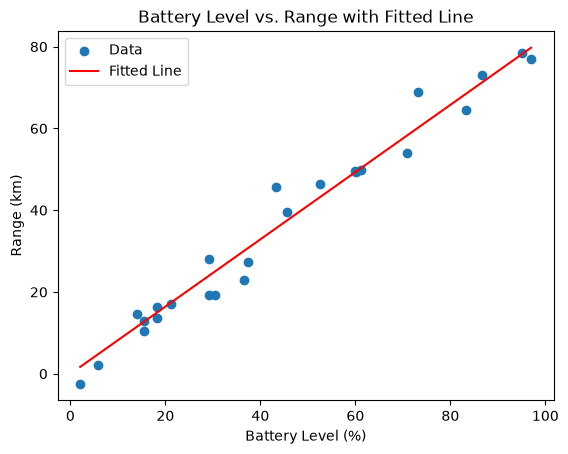

In [468]:
plt.scatter(battery_level, range_km, label = "Data")

x_line = np.array([battery_level.min(), battery_level.max()])
y_line = w_final * x_line + b_final
plt.plot(x_line, y_line, color="red", label="Fitted Line")

plt.xlabel("Battery Level (%)")
plt.ylabel("Range (km)")
plt.title("Battery Level vs. Range with Fitted Line")
plt.legend()
plt.show()

## 8. Make a Prediction

In [469]:
new_battery_levels = [20, 50, 80]  # low, medium, high battery level in %

for level in new_battery_levels:
    predicted_range = w_final * level + b_final
    print(f"Predicted range at {level}% battery: {predicted_range:.2f} km")

Predicted range at 20% battery: 16.43 km
Predicted range at 50% battery: 41.10 km
Predicted range at 80% battery: 65.78 km


## 9. Reflection

Using a learning rate that was too high caused gradient descent to oscillate and
overshoot the minimum instead of converging, eventually producing `NaN` values.
Lowering the learning rate fixed this.

The converged parameters (`w ≈ 0.82`, `b ≈ -0.02`) closely matched the function used
to generate the synthetic data (`range_km = 0.8 * battery_level + noise`), confirming
that gradient descent successfully recovered the underlying relationship.

One limitation of this simple model: since it is purely linear, it can predict a
negative range for very low battery levels, which is physically impossible.